# 한국어 스트리밍 키워드 검출 데모

이 노트북은 [ko-kws-zipformer-tiny](https://huggingface.co/kairess/ko-kws-zipformer-tiny) 모델을
[sherpa-onnx](https://github.com/k2-fsa/sherpa-onnx)로 돌려 봅니다. 모델은 int8 기준 9.3 MB이고, CPU 한 코어로 실시간보다 훨씬 빠르게 돕니다.

1. 키워드를 텍스트로 넣는 방법
2. 예제 음성에서 키워드 검출과 모델이 들은 전사
3. 마이크처럼 100 ms씩 흘려 넣는 실시간 스트림과 검출 지연
4. 잡음 속에서의 검출
5. 문턱값에 따른 놓침과 오탐의 균형
6. 처리 속도
7. 내 음성으로 해 보기

In [1]:
# 필요한 패키지 (없으면 설치)
import importlib.util, subprocess, sys
pkgs = {"sherpa_onnx": "sherpa-onnx", "sentencepiece": "sentencepiece", "soundfile": "soundfile",
        "matplotlib": "matplotlib", "huggingface_hub": "huggingface_hub"}
missing = [p for m, p in pkgs.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("ok")

ok


## 모델 받기

Hugging Face에서 모델을 받습니다. 이미 받아 둔 폴더가 있으면 환경 변수 `KWS_MODEL_DIR`로 지정하세요.

In [2]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", message="IProgress not found")
from huggingface_hub import snapshot_download

REPO_ID = "kairess/ko-kws-zipformer-tiny"
MODEL_DIR = Path(os.environ.get("KWS_MODEL_DIR") or snapshot_download(REPO_ID))

for f in ["encoder.int8.onnx", "decoder.int8.onnx", "joiner.int8.onnx", "tokens.txt", "bpe.model"]:
    print(f"{f:20s} {(MODEL_DIR / f).stat().st_size / 1e6:6.2f} MB")
print(f"{'int8 합계':18s} {sum((MODEL_DIR / f).stat().st_size for f in ['encoder.int8.onnx', 'decoder.int8.onnx', 'joiner.int8.onnx']) / 1e6:6.2f} MB")

encoder.int8.onnx      8.48 MB
decoder.int8.onnx      0.43 MB
joiner.int8.onnx       0.39 MB
tokens.txt             0.02 MB
bpe.model              0.03 MB
int8 합계              9.31 MB


In [3]:
import time, tempfile
import numpy as np
import soundfile as sf
import sentencepiece as spm
import sherpa_onnx
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Audio, display

# 그래프에 한글을 쓰기 위한 글꼴 (없으면 기본 글꼴)
_names = {f.name for f in font_manager.fontManager.ttflist}
for _n in ["NanumGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic", "Noto Serif CJK KR"]:
    if _n in _names:
        plt.rcParams["font.family"] = _n
        break
plt.rcParams["axes.unicode_minus"] = False

SR = 16000
sp = spm.SentencePieceProcessor(model_file=str(MODEL_DIR / "bpe.model"))


def load(path):
    x, sr = sf.read(path, dtype="float32")
    if x.ndim > 1:
        x = x.mean(axis=1)
    if sr != SR:  # 간단한 선형 보간 리샘플링
        t = np.arange(0, len(x) / sr, 1 / SR)
        x = np.interp(t, np.arange(len(x)) / sr, x).astype(np.float32)
    return x


def keyword_line(word, score=1.0, threshold=0.35):
    return f"{' '.join(sp.encode(word, out_type=str))} :{score} #{threshold} @{word}"


def make_spotter(words, threshold=0.35, score=1.0, int8=True, threads=1):
    q = ".int8" if int8 else ""
    kw = tempfile.NamedTemporaryFile("w", suffix=".txt", delete=False, encoding="utf-8")
    kw.write("\n".join(keyword_line(w, score, threshold) for w in words) + "\n")
    kw.close()
    return sherpa_onnx.KeywordSpotter(
        tokens=str(MODEL_DIR / "tokens.txt"), encoder=str(MODEL_DIR / f"encoder{q}.onnx"),
        decoder=str(MODEL_DIR / f"decoder{q}.onnx"), joiner=str(MODEL_DIR / f"joiner{q}.onnx"),
        keywords_file=kw.name, num_threads=threads, keywords_score=score, keywords_threshold=threshold,
        num_trailing_blanks=1, provider="cpu")


def spot(spotter, x, chunk=0.1):
    """마이크처럼 chunk초씩 흘려 넣으며 검출. [(키워드, 검출 시각 s)]"""
    s, hits, n = spotter.create_stream(), [], int(chunk * SR)
    x = np.concatenate([x, np.zeros(SR // 2, np.float32)])  # 끝부분 처리용 무음
    for i in range(0, len(x), n):
        s.accept_waveform(SR, x[i:i + n])
        while spotter.is_ready(s):
            spotter.decode_stream(s)
            r = spotter.get_result(s)
            if r:
                hits.append((r, min(i + n, len(x)) / SR))
                spotter.reset_stream(s)
    return hits


recognizer = sherpa_onnx.OnlineRecognizer.from_transducer(
    tokens=str(MODEL_DIR / "tokens.txt"), encoder=str(MODEL_DIR / "encoder.int8.onnx"),
    decoder=str(MODEL_DIR / "decoder.int8.onnx"), joiner=str(MODEL_DIR / "joiner.int8.onnx"),
    num_threads=1, decoding_method="greedy_search")


def transcribe(x):
    """같은 모델로 스트리밍 음성 인식: (전사, [(토큰, 시각 s)])"""
    s = recognizer.create_stream()
    s.accept_waveform(SR, np.concatenate([x, np.zeros(SR // 2, np.float32)]))
    s.input_finished()
    while recognizer.is_ready(s):
        recognizer.decode_stream(s)
    r = recognizer.get_result_all(s)
    return "".join(r.tokens).strip(), list(zip(r.tokens, r.timestamps))


wav0 = load(MODEL_DIR / "test_wavs/0.wav")
wav1 = load(MODEL_DIR / "test_wavs/1.wav")
print(f"예제 음성: {len(wav0) / SR:.1f}s, {len(wav1) / SR:.1f}s")

예제 음성: 10.0s, 10.1s


## 1. 키워드는 텍스트로 넣습니다

모델은 음절 단위 토큰 2,000개로 말을 받아 적도록 학습했습니다. 키워드는 이 토큰 열로 바꿔 등록하므로, 다시 학습하지 않고 어떤 한국어 단어든 키워드로 쓸 수 있습니다.
`▁`는 단어의 시작을 뜻합니다.

In [4]:
for w in ["대부분", "운전자", "파이어볼", "텔레포트", "불꽃 화살", "하이퍼 스페이스"]:
    print(f"{w:10s} → {keyword_line(w)}")

대부분        → ▁대 부 분 :1.0 #0.35 @대부분
운전자        → ▁ 운 전 자 :1.0 #0.35 @운전자
파이어볼       → ▁파 이 어 볼 :1.0 #0.35 @파이어볼
텔레포트       → ▁ 텔 레 포 트 :1.0 #0.35 @텔레포트
불꽃 화살      → ▁불 꽃 ▁화 살 :1.0 #0.35 @불꽃 화살
하이퍼 스페이스   → ▁하 이 퍼 ▁스 페 이 스 :1.0 #0.35 @하이퍼 스페이스


## 2. 예제 음성에서 검출하기

FLEURS 한국어 테스트 음성 두 개(CC BY 4.0)입니다. 들어 있는 키워드 네 개와 들어 있지 않은 키워드 네 개를 함께 등록했습니다.
같은 ONNX 모델을 음성 인식기로도 돌려, 모델이 실제로 무엇을 들었는지 전사도 함께 봅니다.

In [5]:
PRESENT = ["대부분", "장례식", "운전자", "교통"]
ABSENT = ["대통령", "올림픽", "도서관", "지하철"]
spotter = make_spotter(PRESENT + ABSENT)

for name, x in [("0.wav", wav0), ("1.wav", wav1)]:
    display(Audio(x, rate=SR))
    text, _ = transcribe(x)
    hits = spot(spotter, x)
    print(f"[{name}] 전사: {text}")
    print(f"[{name}] 검출: " + (", ".join(f"{w} ({t:.1f}s)" for w, t in hits) or "없음"))
    print()

[0.wav] 전사: 참석한 인원수가 너무 많은 나머지 대부분이 성 베드로 광장에서 치뤄진 장례식에 입장할 수 없었습니다
[0.wav] 검출: 대부분 (4.4s), 장례식 (6.9s)



[1.wav] 전사: 불행이도 운전자의 행동이 백 프로 확실하다고 예측할 수 없기 때문에 교통그름을 연구하기는 어렵다
[1.wav] 검출: 운전자 (2.8s), 교통 (6.6s)



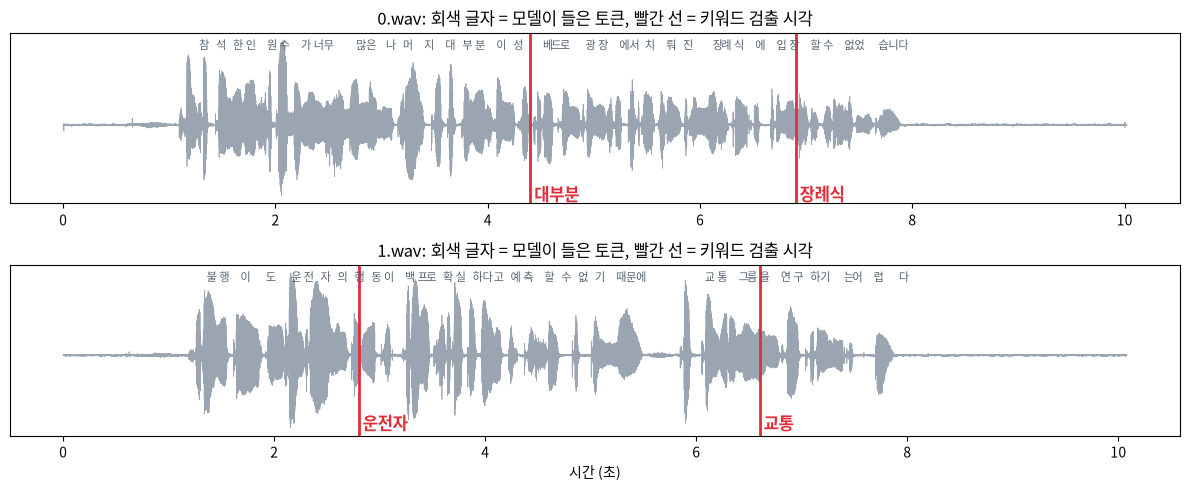

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)
for ax, (name, x) in zip(axes, [("0.wav", wav0), ("1.wav", wav1)]):
    t = np.arange(len(x)) / SR
    ax.plot(t, x, color="#9aa5b1", linewidth=0.5)
    _, toks = transcribe(x)
    for tok, ts in toks:
        ax.text(ts, 0.9 * np.abs(x).max(), tok.strip(), fontsize=8, ha="left", color="#52606d")
    for w, td in spot(spotter, x):
        ax.axvline(td, color="#e12d39", linewidth=2)
        ax.text(td, -0.9 * np.abs(x).max(), f" {w}", color="#e12d39", fontsize=12, fontweight="bold")
    ax.set_title(f"{name}: 회색 글자 = 모델이 들은 토큰, 빨간 선 = 키워드 검출 시각")
    ax.set_yticks([])
axes[-1].set_xlabel("시간 (초)")
plt.tight_layout()
plt.show()

## 3. 실시간 스트림과 검출 지연

마이크 입력처럼 약 40초짜리 스트림을 만들어 100 ms씩 흘려 넣습니다. 사이사이에 조용한 잡음 구간을 넣었습니다.
검출 지연은 키워드의 마지막 음절이 인식된 시각부터 검출이 나온 시각까지입니다.
처리 시간은 100 ms 조각 하나를 처리하는 데 걸린 시간이며, 100 ms보다 작으면 실시간으로 돌 수 있습니다.

In [7]:
rng = np.random.default_rng(0)
room = lambda sec: (0.003 * rng.standard_normal(int(sec * SR))).astype(np.float32)  # 조용한 방 잡음
stream = np.concatenate([room(3), wav0, room(4), wav1, room(4), wav0, room(2)])
print(f"스트림 길이: {len(stream) / SR:.1f}s")

sp_live = make_spotter(PRESENT + ABSENT)
s, n, hits, costs = sp_live.create_stream(), int(0.1 * SR), [], []
for i in range(0, len(stream), n):
    t0 = time.perf_counter()
    s.accept_waveform(SR, stream[i:i + n])
    while sp_live.is_ready(s):
        sp_live.decode_stream(s)
        r = sp_live.get_result(s)
        if r:
            hits.append((r, (i + n) / SR))
            sp_live.reset_stream(s)
    costs.append((time.perf_counter() - t0) * 1000)

_, toks = transcribe(stream)
def last_syllable_time(word, t_detect):
    # 검출 직전에 인식된 토큰 중 키워드 마지막 글자의 시각
    cands = [ts for tok, ts in toks if tok.strip().endswith(word[-1]) and ts <= t_detect]
    return max(cands) if cands else float("nan")

print(f"100 ms 조각 처리 시간: 평균 {np.mean(costs):.1f} ms, 최대 {np.max(costs):.1f} ms")
print()
print("키워드    검출 시각   마지막 음절   지연")
for w, td in hits:
    te = last_syllable_time(w, td)
    print(f"{w:6s}  {td:8.2f}s  {te:10.2f}s  {1000 * (td - te):5.0f} ms")

스트림 길이: 43.1s


100 ms 조각 처리 시간: 평균 1.1 ms, 최대 4.9 ms

키워드    검출 시각   마지막 음절   지연
대부분         7.20s        6.88s    320 ms
장례식         9.80s        9.32s    480 ms
운전자        20.00s       19.52s    480 ms
교통         23.60s       23.20s    400 ms
대부분        35.40s       35.00s    400 ms
장례식        38.00s       37.44s    560 ms


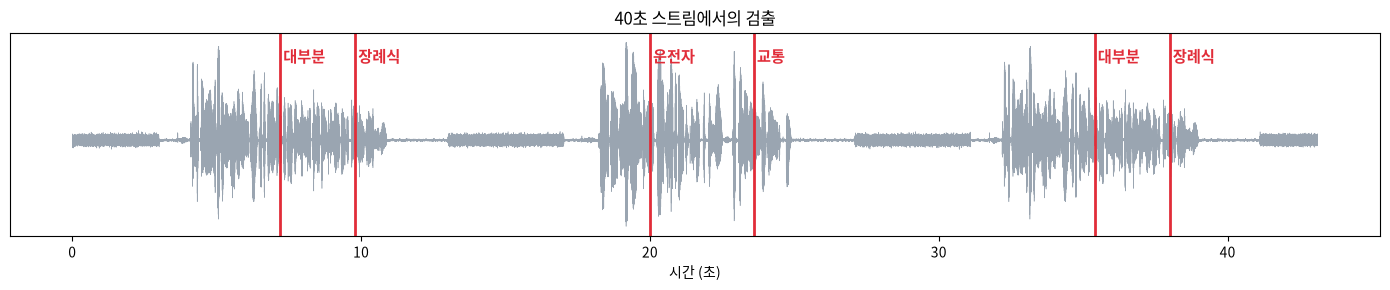

In [8]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(np.arange(len(stream)) / SR, stream, color="#9aa5b1", linewidth=0.4)
for w, td in hits:
    ax.axvline(td, color="#e12d39", linewidth=2)
    ax.text(td, 0.8 * np.abs(stream).max(), f" {w}", color="#e12d39", fontsize=11, fontweight="bold")
ax.set_xlabel("시간 (초)"); ax.set_yticks([]); ax.set_title("40초 스트림에서의 검출")
plt.tight_layout(); plt.show()

## 4. 잡음 속에서

예제 음성 0.wav에 백색 잡음과 사람 목소리 잡음(다른 발화)을 신호 대 잡음비(SNR)별로 섞었습니다.
SNR이 낮을수록 잡음이 큽니다. 0 dB는 말소리와 잡음의 크기가 같은 상태입니다.

In [9]:
def mix(x, noise, snr_db):
    noise = np.resize(noise, len(x))
    p_x, p_n = np.mean(x ** 2), np.mean(noise ** 2) + 1e-12
    return (x + noise * np.sqrt(p_x / (p_n * 10 ** (snr_db / 10)))).astype(np.float32)

white = rng.standard_normal(len(wav0)).astype(np.float32)
babble = wav1  # 다른 사람의 말소리
sp_noise = make_spotter(PRESENT + ABSENT)
rows = []
for kind, noise in [("백색 잡음", white), ("말소리 잡음", babble)]:
    for snr in [20, 10, 5, 0]:
        y = mix(wav0, noise, snr)
        found = [w for w, _ in spot(sp_noise, y)]
        rows.append((kind, snr, found, transcribe(y)[0]))
print("잡음         SNR   검출                      전사")
for kind, snr, found, text in rows:
    print(f"{kind:8s} {snr:3d} dB  {', '.join(found) or '없음':24s}  {text[:40]}")
display(Audio(mix(wav0, babble, 5), rate=SR))

잡음         SNR   검출                      전사
백색 잡음     20 dB  대부분, 장례식                  참석한 인어스가 너무 많은 나머지 대부분이 성 베드로 광장에서 치뤄진 장
백색 잡음     10 dB  대부분, 장례식                  참석한 인어스가 너무 많은 나머지 대부분이 성 백으로 광장에서 치뤄진 장
백색 잡음      5 dB  대부분, 장례식                  참석한 인하수가 너무 많은 나머지 대부분이 성 대기로 광장에서 치뤄진 장
백색 잡음      0 dB  대부분, 장례식                  참석한 인원수가 너무 많이 나오지 대부분이 성 대기로 방산에서 치뤄진 장
말소리 잡음    20 dB  대부분, 장례식                  참석한 인원수가 너무 많은 나머지 대부분이 성 베드로 광장에서 치뤄진 장
말소리 잡음    10 dB  대부분, 장례식                  참석한 인원수가 너무 많은 나머지 대부분이 성 베드로 광장에서 치뤄진 장
말소리 잡음     5 dB  대부분, 장례식                  참석한 인원수가 너무 많은 나머지 대부분이 성 웨더로 광장에서 치뤄진 장
말소리 잡음     0 dB  없음                        참석한 인원수가 환자에 앉은 남편이 되더라구 성적에 들어왔대며 지르신 틱


## 5. 문턱값: 놓침과 오탐의 균형

문턱값(threshold)이 낮으면 키워드를 잘 잡지만 비슷한 소리에도 반응하고, 높으면 오탐은 줄지만 놓치는 키워드가 늘어납니다.
깨끗한 음성과 잡음을 섞은 음성 10개에서, 들어 있는 키워드를 몇 번 잡았는지와 없는 키워드를 몇 번 잘못 잡았는지 셌습니다.

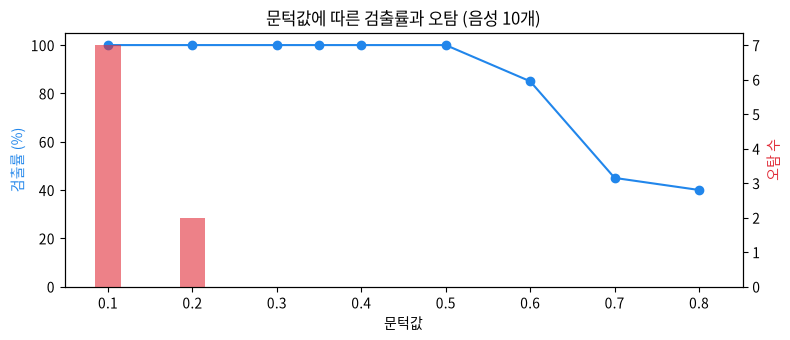

문턱값 0.10: 검출률 100.0%  오탐 7건
문턱값 0.20: 검출률 100.0%  오탐 2건
문턱값 0.30: 검출률 100.0%  오탐 0건
문턱값 0.35: 검출률 100.0%  오탐 0건
문턱값 0.40: 검출률 100.0%  오탐 0건
문턱값 0.50: 검출률 100.0%  오탐 0건
문턱값 0.60: 검출률  85.0%  오탐 0건
문턱값 0.70: 검출률  45.0%  오탐 0건
문턱값 0.80: 검출률  40.0%  오탐 0건


In [10]:
clips = [wav0, wav1] + [mix(w, n, snr) for w in (wav0, wav1) for n, snr in ((white, 10), (white, 5), (babble, 10), (babble, 5))]
# 예제 음성의 원래 전사(FLEURS)에 들어 있는 키워드가 정답
REF = {0: {"대부분", "장례식"}, 1: {"운전자", "교통"}}
truth = [REF[0], REF[1]] + [REF[0]] * 4 + [REF[1]] * 4

ths = [0.1, 0.2, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8]
recall, fas = [], []
for th in ths:
    sp_th = make_spotter(PRESENT + ABSENT, threshold=th)
    tp = fa = total = 0
    for c, want in zip(clips, truth):
        got = set(w for w, _ in spot(sp_th, c))
        tp += len(got & want); total += len(want); fa += len(got - want)
    recall.append(tp / total); fas.append(fa)

fig, ax1 = plt.subplots(figsize=(8, 3.5))
ax1.plot(ths, [100 * r for r in recall], "o-", color="#2186eb", label="검출률 (%)")
ax1.set_xlabel("문턱값"); ax1.set_ylabel("검출률 (%)", color="#2186eb"); ax1.set_ylim(0, 105)
ax2 = ax1.twinx()
ax2.bar(ths, fas, width=0.03, color="#e12d39", alpha=0.6, label="오탐 수")
ax2.set_ylabel("오탐 수", color="#e12d39")
ax1.set_title("문턱값에 따른 검출률과 오탐 (음성 10개)")
plt.tight_layout(); plt.show()
for th, r, f in zip(ths, recall, fas):
    print(f"문턱값 {th:.2f}: 검출률 {100 * r:5.1f}%  오탐 {f}건")

## 6. 처리 속도

실시간 비율(RTF)은 음성 1초를 처리하는 데 걸린 시간입니다. 0.01이면 실시간보다 100배 빠릅니다. CPU 스레드 하나로 쟀습니다.

In [11]:
long = np.concatenate([wav0, wav1] * 5)
for int8 in (True, False):
    sp_speed = make_spotter(PRESENT, int8=int8)
    t0 = time.perf_counter(); spot(sp_speed, long, chunk=0.32); dt = time.perf_counter() - t0
    size = sum((MODEL_DIR / f"{p}{'.int8' if int8 else ''}.onnx").stat().st_size for p in ("encoder", "decoder", "joiner")) / 1e6
    print(f"{'int8' if int8 else 'fp32'}: 모델 {size:5.1f} MB, RTF {dt / (len(long) / SR):.4f} ({len(long) / SR:.0f}s 음성을 {dt:.2f}s에 처리)")

int8: 모델   9.3 MB, RTF 0.0113 (100s 음성을 1.14s에 처리)


fp32: 모델  25.4 MB, RTF 0.0127 (100s 음성을 1.28s에 처리)


## 7. 내 음성으로 해 보기

16 kHz가 아니어도 됩니다. 녹음 파일 경로와 찾을 키워드를 바꿔 실행하세요.
Colab에서는 왼쪽 파일 창에 파일을 올린 뒤 경로를 적으면 됩니다.

In [12]:
MY_WAV = "my_voice.wav"          # 내 녹음 파일
MY_KEYWORDS = ["파이어볼", "텔레포트", "대부분"]
THRESHOLD = 0.35

if Path(MY_WAV).exists():
    x = load(MY_WAV)
    display(Audio(x, rate=SR))
    print("전사:", transcribe(x)[0])
    print("검출:", spot(make_spotter(MY_KEYWORDS, threshold=THRESHOLD), x) or "없음")
else:
    print(f"{MY_WAV} 파일이 없습니다. 경로를 바꿔 다시 실행하세요.")

my_voice.wav 파일이 없습니다. 경로를 바꿔 다시 실행하세요.


## 참고

- 모델 성능, 학습 데이터, 한계는 [모델 카드](https://huggingface.co/kairess/ko-kws-zipformer-tiny)와 이 저장소의 README에 있습니다.
- 잡음이 많은 환경에서는 오탐이 늘어납니다. 서비스에서는 문턱값을 0.5 안팎으로 올리거나, 키워드마다 문턱값을 따로 두세요(`#문턱값`).
- 키워드 가산점(`:score`)을 올리면 짧거나 흔하지 않은 키워드를 더 잘 잡지만 오탐도 늘어납니다.